# 01 · Filters and photometry

How a spectrum becomes a magnitude, and the three choices hidden in that sentence.

**Execution model — run end-to-end.** Everything here reads `data/` and takes a few
seconds. No merger tree, no galaxies: this rung is about filter curves and single
stellar populations.

By the end you should be able to answer:

1. What a filter curve *is*, and why loading one needs care.
2. Where a band actually sits — pivot wavelength, and edges that do not depend on sampling.
3. How to turn one SSP spectrum into one AB magnitude, by hand.
4. Why photometry is a **matrix**, and what that buys.
5. Why two people integrating the same spectrum through the same filter get different
   answers — the convention question, settled by measurement in August 2026.
6. Why L-GALAXIES' own magnitudes disagree with ours by ~7 mmag, and why that is
   *its* arithmetic rather than ours.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path('..').resolve()

plt.rcParams.update({'figure.dpi': 110, 'font.size': 9,
                     'axes.grid': True, 'grid.alpha': 0.25})

# Okabe-Ito, colour-blind safe. Used consistently for the five SDSS bands below.
BAND_COLOURS = {'u': '#0072B2', 'g': '#009E73', 'r': '#D55E00',
                'i': '#CC79A7', 'z': '#7B4F9D'}
print(f'project root: {PROJECT_ROOT}')

project root: /Users/suteepornz/Documents/Suttikoon/Research_Projects/GALsPeCtrA


---

## 1. Loading a filter curve

A filter curve is two columns: wavelength and transmission. The difficulty is that
nobody agrees on the units or the header.

`galspectra.photometry.filter_sets.load_curve` exists for exactly that reason. It
handles the three header conventions in the curves this project ships, and it takes the
wavelength unit explicitly — **PAUS curves are in nanometres**, and a silent factor of
ten would put every narrow band in the wrong place and still produce plausible-looking
magnitudes.

In [3]:
from galspectra.photometry.filter_sets import FILTER_SET_LOADERS, load_filter_set

sets = {name: load_filter_set(name) for name in FILTER_SET_LOADERS}

print(f'{"set":12s}{"bands":>7}   first band')
for name, curves in sets.items():
    first = next(iter(curves))
    w, t = curves[first]
    print(f'{name:12s}{len(curves):7d}   {first:12s} {w.min():8.0f}-{w.max():8.0f} AA, '
          f'peak T = {t.max():.3f}')

total = sum(len(c) for c in sets.values())
print(f'\n{total} curves across {len(sets)} sets')

set           bands   first band
paus_nb          40   NB455            3000-   10992 AA, peak T = 0.423
paus_bb           6   PAU_u            3000-   10992 AA, peak T = 0.279
megacam           5   MegaCam_u        3000-    4200 AA, peak T = 0.401
euclid            4   VIS              4369-    9866 AA, peak T = 0.760
2mass_ks          1   2MASS_Ks        19000-   23990 AA, peak T = 1.000
lgal_sdss         5   u                2980-    4130 AA, peak T = 0.108

61 curves across 6 sets


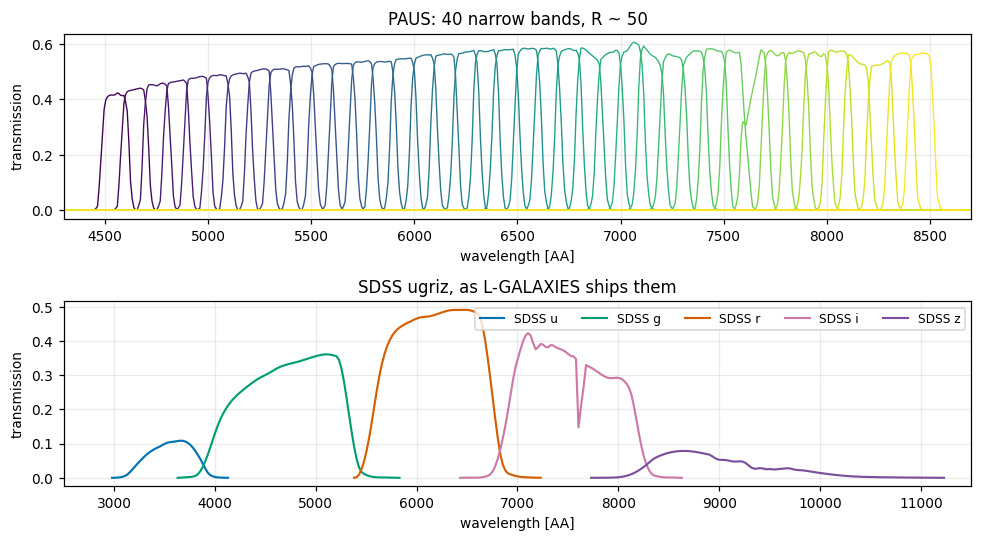

In [4]:
# The PAUS narrow bands: 40 filters, 100 AA wide, 100 AA apart. This is the instrument
# the whole programme is aimed at, and the reason a broad-band-only pipeline is not enough.
fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=False)

ax = axes[0]
for i, (name, (w, t)) in enumerate(sets['paus_nb'].items()):
    ax.plot(w, t, lw=0.9, color=plt.cm.viridis(i / 39))
ax.set(xlim=(4300, 8700), xlabel='wavelength [AA]', ylabel='transmission',
       title='PAUS: 40 narrow bands, R ~ 50')

ax = axes[1]
for b, (w, t) in sets['lgal_sdss'].items():
    ax.plot(w, t, lw=1.4, color=BAND_COLOURS.get(b, 'grey'), label=f'SDSS {b}')
ax.set(xlim=(2500, 11500), xlabel='wavelength [AA]', ylabel='transmission',
       title="SDSS ugriz, as L-GALAXIES ships them")
ax.legend(ncol=5, fontsize=8)
fig.tight_layout()

---

## 2. Where a band actually sits

Two numbers describe a band's position, and neither is "the peak".

**Pivot wavelength** is the one that makes $f_\lambda \leftrightarrow f_\nu$ conversion
exact for that band:

$$\lambda_{\rm pivot} = \sqrt{\frac{\int T\,\lambda\,d\lambda}{\int T\,d\lambda/\lambda}}$$

**Edges** are where transmission crosses some fraction of peak. The threshold matters
more than people expect: PAUS narrow bands leak red to ~10000 AA at 0.1 % of peak, which
is what set the red end of this project's wavelength requirement.

Both definitions are imported from `scripts/wavelength_requirements.py` rather than
rewritten here, so this notebook cannot drift from the number the requirement was
computed with.

In [5]:
import sys
sys.path.insert(0, str(PROJECT_ROOT / 'scripts'))
from wavelength_requirements import curve_edges, pivot_wavelength

rows = []
for b, (w, t) in sets['lgal_sdss'].items():
    lo1, hi1 = curve_edges(w, t, 0.01)     # 1% of peak
    lo3, hi3 = curve_edges(w, t, 0.001)    # 0.1% of peak
    rows.append((b, pivot_wavelength(w, t), lo1, hi1, hi3 - hi1))

print(f'{"band":6s}{"pivot":>9}{"blue@1%":>10}{"red@1%":>10}{"extra red at 0.1%":>19}')
for b, piv, lo, hi, leak in rows:
    print(f'{b:6s}{piv:9.0f}{lo:10.0f}{hi:10.0f}{leak:19.0f}')

band      pivot   blue@1%    red@1%  extra red at 0.1%
u          3557      3048      4028                 88
g          4702      3783      5549                223
r          6176      5415      6989                183
i          7490      6689      8389                197
z          8947      7960     10833                352


widest 0.1% red edge: 10225 AA  (pivot 6559 AA)


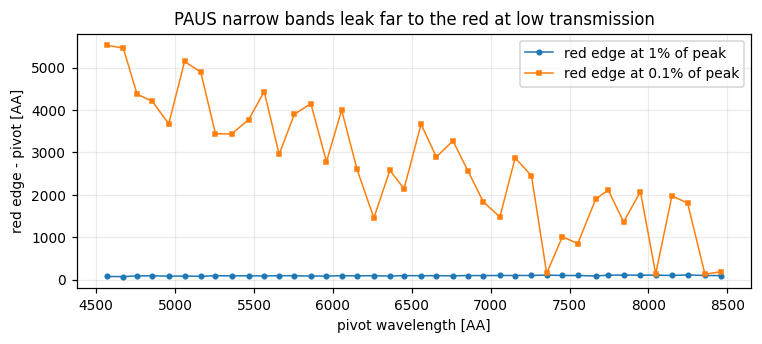

In [6]:
# The same for the narrow bands: the leak is the point.
leaks = []
for name, (w, t) in sets['paus_nb'].items():
    _lo, hi1 = curve_edges(w, t, 0.01)
    _lo, hi3 = curve_edges(w, t, 0.001)
    leaks.append((pivot_wavelength(w, t), hi1, hi3))

piv, e1, e3 = np.array(leaks).T
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(piv, e1 - piv, 'o-', ms=3, lw=1, label='red edge at 1% of peak')
ax.plot(piv, e3 - piv, 's-', ms=3, lw=1, label='red edge at 0.1% of peak')
ax.set(xlabel='pivot wavelength [AA]', ylabel='red edge - pivot [AA]',
       title='PAUS narrow bands leak far to the red at low transmission')
ax.legend()
fig.tight_layout()

print(f'widest 0.1% red edge: {e3.max():.0f} AA  (pivot {piv[np.argmax(e3)]:.0f} AA)')

---

## 3. One SSP, one magnitude, by hand

The AB magnitude is a **weighted average of $f_\nu$ across the passband**, converted to
a magnitude:

$$m_{\rm AB} = -2.5\log_{10}\langle f_\nu\rangle - 48.6,
\qquad
\langle f_\nu\rangle = \frac{\int f_\nu\,w\,d\nu}{\int w\,d\nu}$$

Everything interesting is in $w$. Do it explicitly first; the library call comes after,
and the two must agree.

The SSP grid is `data/sed_grid_bc03.npz` — 1200 BC03 simple stellar populations on 831
wavelength bins, in $L_\odot$/AA per $M_\odot$ formed.

In [7]:
grid = np.load(PROJECT_ROOT / 'data' / 'sed_grid_bc03.npz', allow_pickle=True)
wave = np.asarray(grid['wave'], dtype=float)          # AA
seds = np.asarray(grid['seds'], dtype=float)          # (1200, 831)
params = np.asarray(grid['params'], dtype=float)      # (tage/Gyr, log Z/Zsun)

age, logz = params[:, 0], params[:, 1]
solar = np.isclose(logz, 0.0)

young_i = int(np.flatnonzero(solar & (age > 0.009) & (age < 0.02))[0])
old_i = int(np.flatnonzero(solar & (age > 10.0))[0])
print(f'grid: {seds.shape[0]} SSPs x {wave.size} bins, {wave.min():.0f}-{wave.max():.0f} AA')
print(f'young: {age[young_i]*1e3:.0f} Myr   old: {age[old_i]:.1f} Gyr   (both solar Z)')

grid: 1200 SSPs x 831 bins, 805-29950 AA
young: 9 Myr   old: 10.2 Gyr   (both solar Z)


In [8]:
C_ANG_S = 2.99792458e18   # speed of light in AA/s

def ab_magnitude_by_hand(wave_ang, f_lam, filt_wave, filt_trans, weight='photon'):
    """The whole calculation, written out.

    Three steps, and the third is the one with a choice in it:
      1. f_lambda -> f_nu           (f_nu = f_lam * lambda^2 / c)
      2. put the filter on the spectrum's wavelength grid
      3. average f_nu over the band, weighted by w, and take -2.5 log10
    """
    f_nu = f_lam * wave_ang**2 / C_ANG_S
    nu = C_ANG_S / wave_ang

    T = np.interp(wave_ang, filt_wave, filt_trans, left=0.0, right=0.0)

    order = np.argsort(nu)                 # integrate with nu increasing
    nu_s, fnu_s, T_s = nu[order], f_nu[order], T[order]

    # 'energy' weights each frequency by the transmission; 'photon' divides by h*nu,
    # because a CCD counts photons rather than integrating energy.
    w = T_s if weight == 'energy' else T_s / nu_s

    mean_f_nu = np.trapezoid(fnu_s * w, nu_s) / np.trapezoid(w, nu_s)
    return -2.5 * np.log10(mean_f_nu) - 48.6


w_r, t_r = sets['lgal_sdss']['r']
by_hand = ab_magnitude_by_hand(wave, seds[old_i], w_r, t_r)
print(f'r-band magnitude of a {age[old_i]:.1f} Gyr solar SSP, by hand: {by_hand:.6f}')
print('(the absolute zero point is arbitrary here - the SED is per solar mass,')
print(' not a flux at a distance. Colours and differences are what matter.)')

r-band magnitude of a 10.2 Gyr solar SSP, by hand: -93.664603
(the absolute zero point is arbitrary here - the SED is per solar mass,
 not a flux at a distance. Colours and differences are what matter.)


In [9]:
from galspectra.photometry.synthetic import compute_ab_magnitudes

lib = compute_ab_magnitudes(wave, seds[old_i], sets['lgal_sdss'])
print(f'{"band":6s}{"by hand":>12}{"library":>12}{"difference":>14}')
for b, (fw, ft) in sets['lgal_sdss'].items():
    mine = ab_magnitude_by_hand(wave, seds[old_i], fw, ft)
    print(f'{b:6s}{mine:12.6f}{lib[b]:12.6f}{abs(mine - lib[b]):14.2e}')

print('\nThe library is the same calculation. If this ever stops agreeing,')
print('the notebook is right and the library has a bug.')

band       by hand     library    difference
u       -91.025469  -91.025469      0.00e+00
g       -92.832484  -92.832484      0.00e+00
r       -93.664603  -93.664603      0.00e+00
i       -94.011280  -94.011280      0.00e+00
z       -94.360670  -94.360670      0.00e+00

The library is the same calculation. If this ever stops agreeing,
the notebook is right and the library has a bug.


---

## 4. Photometry is a matrix

Look again at $\langle f_\nu\rangle$: for a **fixed** wavelength grid and a fixed
filter, it is a linear functional of the spectrum. Nothing about it depends on which
spectrum you feed it.

So the whole of photometry — every band, every galaxy — is one matrix product:

$$\text{band flux} = \text{flux} \cdot P^{\mathsf T}$$

That is what `pca.metrics.BandOperator` builds. It matters more than it looks: because
band flux is *linear* in the spectrum, and a composite stellar population is a
mass-weighted **sum** of SSPs, you can compute a galaxy's photometry without ever
building its spectrum. The error-vs-bytes budget (rung 07) rests entirely on this.

The operator is an optimisation, so it has to give the same answer as the code it
replaces. Check it here rather than trusting it.

In [10]:
from galspectra.pca.metrics import BandOperator

op = BandOperator(wave, sets['lgal_sdss'])
print(f'operator: {op.P.shape[0]} bands x {op.P.shape[1]} wavelengths, '
      f'{op.P.nbytes / 1024:.0f} kB')

worst = 0.0
for i in (young_i, old_i, 0, 599, 1199):
    ref = compute_ab_magnitudes(wave, seds[i], sets['lgal_sdss'])
    fast = op.magnitudes(seds[i])
    worst = max(worst, max(abs(ref[b] - fast[op.index(b)]) for b in op.names))
print(f'worst |BandOperator - compute_ab_magnitudes| over 5 SSPs: {worst:.3e} mag')
assert worst < 1e-10, 'the fast path and the production path have diverged'
print('bit-identical, as tests/test_pca_basis_linearity.py also pins')

operator: 5 bands x 831 wavelengths, 32 kB
worst |BandOperator - compute_ab_magnitudes| over 5 SSPs: 0.000e+00 mag
bit-identical, as tests/test_pca_basis_linearity.py also pins


In [11]:
# Linearity, demonstrated: the band flux of a mass-weighted sum of SSPs equals the
# mass-weighted sum of their band fluxes. This is the property the pipeline is built on.
rng = np.random.default_rng(1)
masses = rng.uniform(0, 1e9, size=seds.shape[0])

lhs = op.band_flux(masses @ seds)        # build the composite spectrum, then integrate
rhs = masses @ op.band_flux(seds)        # integrate every SSP, then sum

print(f'max relative difference: {np.abs(lhs - rhs).max() / np.abs(rhs).max():.3e}')
print('Exact to round-off. A galaxy never needs its spectrum built to be photometered.')

max relative difference: 7.938e-16
Exact to round-off. A galaxy never needs its spectrum built to be photometered.


---

## 5. The weight, and why it is not obvious

Back to $w$. Two defensible choices:

$$\text{energy: } \langle f_\nu\rangle = \frac{\int f_\nu T\,d\nu}{\int T\,d\nu}
\qquad
\text{photon: } \langle f_\nu\rangle = \frac{\int f_\nu T\,d\nu/\nu}{\int T\,d\nu/\nu}$$

They differ because a detector that **counts photons** weights each frequency by
$1/h\nu$ relative to one that integrates **energy**. A CCD counts photons.

The two agree exactly for a source that is flat in $f_\nu$ across the band. They diverge
for anything with colour inside the passband — and the divergence grows with how red the
spectrum is, which is why this matters for old populations and barely at all for young
ones.

This was settled by measurement, not argument (`documents/filter_convention.md`):
integrating BC03 SSPs under both and comparing against L-GALAXIES' own tables, **photon
counting is closer in 30 of 40 bands and in every SDSS band**, and it halves the
old-population $g-r$ offset. It has been the default since 7 August 2026.

In [12]:
def colour(i, convention):
    m = compute_ab_magnitudes(wave, seds[i], sets['lgal_sdss'], convention=convention)
    return m['g'] - m['r']

print(f'{"population":22s}{"energy":>10}{"photon":>10}{"difference":>13}')
for label, i in (('young, 10 Myr', young_i), ('old, >10 Gyr', old_i)):
    e, p = colour(i, 'energy'), colour(i, 'photon')
    print(f'{label:22s}{e:10.4f}{p:10.4f}{e - p:13.4f}')

print('\nThe choice is worth ~0.001 mag for a young population and ~0.02 for an old one.')
print('It is not a rounding decision: it moves red galaxies and leaves blue ones alone,')
print('which is exactly the pattern that looked like a compression artefact for months.')

population                energy    photon   difference
young, 10 Myr             0.0471    0.0517      -0.0045
old, >10 Gyr              0.8551    0.8321       0.0230

The choice is worth ~0.001 mag for a young population and ~0.02 for an old one.
It is not a rounding decision: it moves red galaxies and leaves blue ones alone,
which is exactly the pattern that looked like a compression artefact for months.


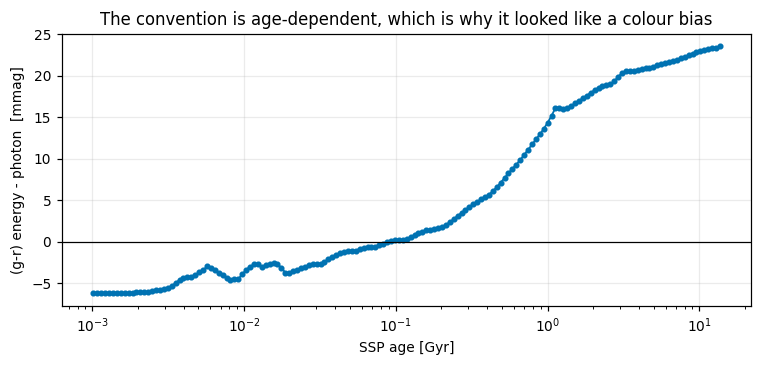

In [13]:
# The same across the full age range, at solar metallicity.
sel = np.flatnonzero(solar & (age > 1e-3))
ages_sel = age[sel]
d_gr = np.array([colour(i, 'energy') - colour(i, 'photon') for i in sel])

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.semilogx(ages_sel, d_gr * 1e3, 'o-', ms=3, lw=1.2, color='#0072B2')
ax.axhline(0, color='k', lw=0.8)
ax.set(xlabel='SSP age [Gyr]', ylabel='(g-r) energy - photon  [mmag]',
       title='The convention is age-dependent, which is why it looked like a colour bias')
fig.tight_layout()

---

## 6. What L-GALAXIES does differently

One more thing a reader who has got this far needs to know: **the reference is
approximate.**

L-GALAXIES ships precomputed `PhotTables`, and validation in this project means
comparing against them. They are written by `setup_Spec_LumTables_onthefly()` in
`code/model_spectro_photometric.c` — from the *same* `FullSEDs` and the *same* filter
curves used above. Two implementations of one integral. They disagree by ~7 mmag in
*ugriz*, and after the convention was settled that disagreement was the last unexplained
systematic in the whole pipeline.

It is not a library difference. It is three defects in that routine's arithmetic:

1. the in-band average is taken in $d\lambda$, not $d\nu$ — weight $\propto T$, one
   power of $\lambda$ beyond photon counting;
2. `integrate()` never multiplies by the step size, on a grid whose spacing runs from
   4 to 100 AA across the library;
3. `interpolate()` does not interpolate — it **steps** the filter curve onto the SSP grid.

Defect 2 is the *smallest* term in *ugriz*, and the cell below shows why: inside the
optical the BC03 grid happens to be uniform, so a missing step size largely cancels
between numerator and denominator. It bites in the UV and IR, where the spacing changes
— which is exactly why the residual is larger outside 3200–9500 AA, the observation that
falsified the earlier "different spectral library" explanation.

`galspectra.photometry.lgal_quadrature` reproduces all three deliberately. Reproducing
them closes the gap to $2\times10^{-6}$ mag. Full account in
`documents/lgalaxies_quadrature.md`.

SSP grid spacing inside the r band: 20-20 AA (93 points)

Uniform, so defect 2 (the missing step size) largely cancels *here* -
numerator and denominator share the same spacing. It bites where the grid
changes, which is why the residual is worst outside the optical:
     805-  3200 AA: spacing   4.0-  20.0 AA,  230 points
    3200-  9500 AA: spacing  10.0-  20.0 AA,  316 points
    9500- 29950 AA: spacing  20.0- 100.0 AA,  285 points


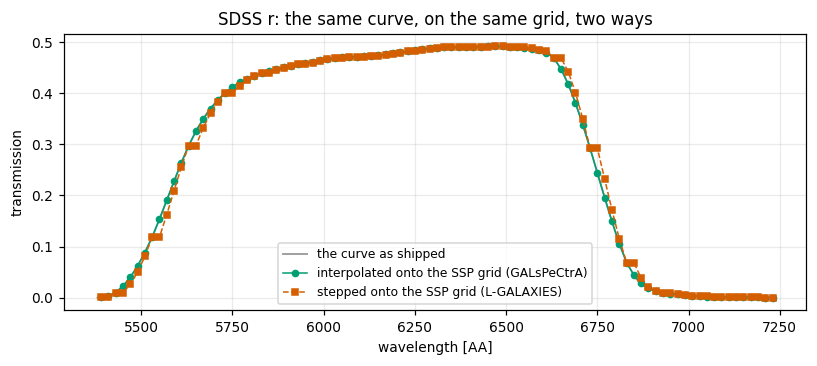

In [14]:
from galspectra.photometry.lgal_quadrature import compute_lgal_magnitudes

# The stepped filter, drawn. This is defect 3, and it is the easiest to see.
from galspectra.photometry.lgal_quadrature import lgal_sample_on_grid

lo, hi = w_r[0], w_r[-1]
band_grid = wave[(wave >= lo) & (wave <= hi)]
stepped = lgal_sample_on_grid(band_grid, w_r, t_r)
smooth = np.interp(band_grid, w_r, t_r, left=0.0, right=0.0)

fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.plot(w_r, t_r, lw=1.2, color='0.6', label='the curve as shipped')
ax.plot(band_grid, smooth, 'o-', ms=4, lw=1, color='#009E73',
        label='interpolated onto the SSP grid (GALsPeCtrA)')
ax.plot(band_grid, stepped, 's--', ms=4, lw=1, color='#D55E00',
        label='stepped onto the SSP grid (L-GALAXIES)')
ax.set(xlabel='wavelength [AA]', ylabel='transmission',
       title='SDSS r: the same curve, on the same grid, two ways')
ax.legend(fontsize=8)
fig.tight_layout()

gaps = np.diff(band_grid)
print(f'SSP grid spacing inside the r band: {gaps.min():.0f}-{gaps.max():.0f} AA '
      f'({band_grid.size} points)')
print('\nUniform, so defect 2 (the missing step size) largely cancels *here* -')
print('numerator and denominator share the same spacing. It bites where the grid')
print('changes, which is why the residual is worst outside the optical:')

edges = [(805, 3200), (3200, 9500), (9500, 29950)]
for lo_e, hi_e in edges:
    m = (wave >= lo_e) & (wave <= hi_e)
    g = np.diff(wave[m])
    print(f'  {lo_e:6d}-{hi_e:6d} AA: spacing {g.min():5.1f}-{g.max():6.1f} AA, '
          f'{m.sum():4d} points')

In [15]:
# And the effect on a magnitude. Colours again, so the zero points cancel.
print(f'{"population":22s}{"photon":>10}{"lgal_native":>13}{"difference":>13}')
for label, i in (('young, 10 Myr', young_i), ('old, >10 Gyr', old_i)):
    ours = compute_ab_magnitudes(wave, seds[i], sets['lgal_sdss'])
    theirs = compute_lgal_magnitudes(wave, seds[i], sets['lgal_sdss'])
    a = ours['g'] - ours['r']
    b = theirs['g'] - theirs['r']
    print(f'{label:22s}{a:10.4f}{b:13.4f}{a - b:13.4f}')

print('\nMeasured over 221 ages x 6 metallicities x 40 bands, reproducing all three')
print('defects takes the SDSS residual against PhotTables from 6.8 mmag to 2.4e-6 mag.')
print('\nSo when this project reports agreement with L-GALAXIES to ~0.01 mag, part of')
print('that difference is the model, not the pipeline. Do not drive it to zero:')
print('that would mean reproducing the defect. See documents/lgalaxies_quadrature.md.')

population                photon  lgal_native   difference
young, 10 Myr             0.0517       0.0575      -0.0058
old, >10 Gyr              0.8321       0.8060       0.0261

Measured over 221 ages x 6 metallicities x 40 bands, reproducing all three
defects takes the SDSS residual against PhotTables from 6.8 mmag to 2.4e-6 mag.

So when this project reports agreement with L-GALAXIES to ~0.01 mag, part of
that difference is the model, not the pipeline. Do not drive it to zero:
that would mean reproducing the defect. See documents/lgalaxies_quadrature.md.


---

## What to take away

1. **A magnitude is a weighted average of $f_\nu$**, and the weight is a choice. Photon
   counting is the right one and this project uses it.
2. **Photometry is linear in the spectrum**, so it is a matrix — which is what lets a
   galaxy be photometered without building its spectrum.
3. **Check the fast path against the slow one**, every time. The assertion in §4 is
   cheap and it is the reason the harness can be trusted.
4. **The reference is approximate.** Agreement with L-GALAXIES' tables is a sanity check,
   not a target to minimise.

**Next rung:** `02_ssp_library_and_pca_basis.ipynb` — where the spectra in §3 come from,
and how 831 wavelength bins become 50 numbers.